# Testing DATA integration through Tango

This notebook checks the real-hardware DATA flow:

1. Connect to Tango devices.
2. Configure the DATA Tango device.
3. Acquire a STEM image from ThermoMicroscope.
4. Use the returned saved file path to retrieve data through the DATA device.


### Quick Start Code Cell

In [1]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt


## 0. Ping Tango servers


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "10.46.217.241"
DB_HOST = "127.0.0.1"
# DB_PORT = 9094
DB_PORT = 9094
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
               ("scan", "asyncroscopy.hardware.SCAN"),
               ("eds", "asyncroscopy.detectors.EDS"),
               ("camera", "asyncroscopy.detectors.CAMERA"),
               ("data", "asyncroscopy.software.DATA"),
               ("corrector", "asyncroscopy.hardware.CORRECTOR"),
               ("microscope", "asyncroscopy.ThermoMicroscope")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}


def wait_for_device(name, timeout=2, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)")
            return True
        except Exception:
            print(".", end="", flush=True)
            time.sleep(interval)
    print(f" ❌ timed out after {timeout}s")
    return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try:
                print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except Exception:
                print(f"  {label}: (no output yet)")



if not all(wait_for_device(f"asyncroscopy/{d}/default") for d in ["stage", "scan", "eds", "camera", "data"]):
    print("\n⚠️  Debug info:")
    check_processes("stage", "scan", "eds", "camera", "data")
    raise RuntimeError("One or more device servers failed.")


print("\n✅ All servers ready!")



  Waiting for asyncroscopy/stage/default... ✅ ready (0.0s)
  Waiting for asyncroscopy/scan/default... ✅ ready (0.0s)
  Waiting for asyncroscopy/eds/default... ✅ ready (0.0s)
  Waiting for asyncroscopy/camera/default... ✅ ready (0.0s)
  Waiting for asyncroscopy/data/default... ✅ ready (0.0s)

✅ All servers ready!


## 1. Connect to devices

In [3]:
SCAN_DEVICE = "asyncroscopy/scan/default"
MICROSCOPE_DEVICE = "asyncroscopy/microscope/default"
DATA_DEVICE = "asyncroscopy/data/default"

In [4]:
scan = tango.DeviceProxy(SCAN_DEVICE)
microscope = tango.DeviceProxy(MICROSCOPE_DEVICE)


for proxy in (scan, microscope):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())


scan      : ON
microscope: ON


In [5]:
data = tango.DeviceProxy(DATA_DEVICE)
data.set_timeout_millis(120_000)

# TILED_HOST = "10.46.217.241"
# TILED_PORT = 9091
# save_path = "D:/microscopedata/tiled/ahoust17/"

TILED_HOST = "127.0.0.1"
TILED_PORT = 9091
save_path = '/Users/austin/Desktop/new_data/'

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path

# print(json.dumps(json.loads(data.get_config()), indent=2))

'{"host": "127.0.0.1", "port": 9091, "uri": "http://127.0.0.1:9091", "save_path": "/Users/austin/Desktop/new_data/", "tiled_server": "no", "tiled_server_status": ""}'

In [6]:
# Start a real Tiled server if the configured DATA server is not already reachable.
if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))
if config.get("tiled_server") != "yes":
    raise RuntimeError("Tiled server did not start. Check DATA device logs and save_path permissions.")


Tiled server is not responding; starting it from the DATA device...
{
  "host": "127.0.0.1",
  "port": 9091,
  "uri": "http://127.0.0.1:9091",
  "save_path": "/Users/austin/Desktop/new_data/",
  "tiled_server": "yes",
  "tiled_server_status": "running; watcher started"
}


In [7]:
from tiled.client import from_uri
import matplotlib.pyplot as plt

client = from_uri("http://127.0.0.1:9091")
list(client)

['stem_image_haadf_20260522T105051975754.tiff',
 'stem_image_haadf_20260522T121318386154.tiff',
 'stem_image_haadf_20260522T121744296246.tiff',
 'stem_image_haadf_20260522T104941655770.tiff',
 'stem_image_haadf_20260522T121544526198.tiff',
 'stem_image_haadf_20260522T105103408463.tiff',
 'stem_image_haadf_20260522T121448707630.tiff',
 'stem_image_haadf_20260522T104922343816.tiff',
 'stem_image_haadf_20260522T121735109675.tiff',
 'stem_image_haadf_20260522T121309985914.tiff',
 'stem_image_haadf_20260522T105025195581.tiff',
 'stem_image_haadf_20260522T104911280047.tiff',
 'stem_image_haadf_20260522T121606892035.tiff',
 'stem_image_haadf_20260522T121713644725.tiff']

## 3. Configure a small STEM acquisition

In [8]:
scan.Activate(["haadf"])
scan.dwell_time = 10e-6
scan.imsize = 256

print("dwell_time:", scan.dwell_time)
print("imsize    :", scan.imsize)


dwell_time: 1e-05
imsize    : 256


## 4. Acquire and inspect the saved path

Saved file: stem_image_haadf_20260522T133103139329.tiff


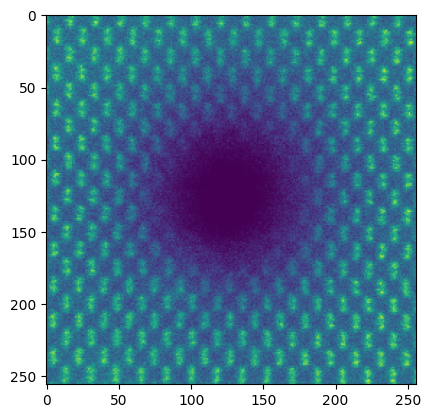

In [10]:
saved_path = microscope.get_scanned_image()

print("Saved file:", saved_path)

time.sleep(2)

image = client[saved_path].read()

plt.figure()
plt.imshow(image)

In [11]:
list(client)

['stem_image_haadf_20260522T105051975754.tiff',
 'stem_image_haadf_20260522T121318386154.tiff',
 'stem_image_haadf_20260522T121744296246.tiff',
 'stem_image_haadf_20260522T133103139329.tiff',
 'stem_image_haadf_20260522T133056564985.tiff',
 'stem_image_haadf_20260522T104941655770.tiff',
 'stem_image_haadf_20260522T121544526198.tiff',
 'stem_image_haadf_20260522T105103408463.tiff',
 'stem_image_haadf_20260522T121448707630.tiff',
 'stem_image_haadf_20260522T104922343816.tiff',
 'stem_image_haadf_20260522T121735109675.tiff',
 'stem_image_haadf_20260522T121309985914.tiff',
 'stem_image_haadf_20260522T105025195581.tiff',
 'stem_image_haadf_20260522T104911280047.tiff',
 'stem_image_haadf_20260522T121606892035.tiff',
 'stem_image_haadf_20260522T121713644725.tiff']

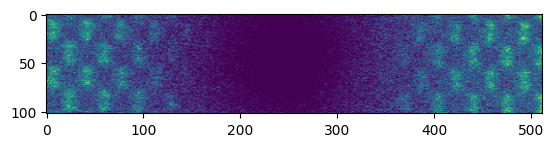

In [12]:
scan.imsize = 512
scan.dwell_time = 1e-6
scan.scan_region = [0, 0.4, 1, 0.2]  # left, top, width, height; relative [0, 1]
scan.haadf = True
scan.bf = False

key = microscope.get_scanned_image_advanced()
time.sleep(2)

image = client[key].read()

plt.figure()
plt.imshow(image)

In [13]:
keys = []
for i in range(10):

    key = microscope.get_scanned_image_advanced()
    keys.append(key)


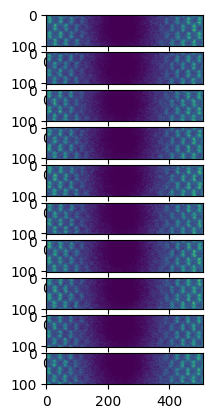

In [14]:
fig, ax = plt.subplots(10,1)


for i in range(10):

    image = client[keys[i]].read()
    ax[i].imshow(image)

In [15]:
image

array([[12574, 15358, 11906, ..., 17069, 26277, 20272],
       [16624, 13483, 19093, ..., 18839, 22338, 23110],
       [14054, 22508, 15787, ..., 19580, 26412, 18255],
       ...,
       [ 6518,  9758, 10944, ..., 26074, 12909, 18232],
       [19171, 16043, 26979, ..., 23482, 22506, 15877],
       [13424, 17607, 18318, ..., 20951, 22777, 16073]],
      shape=(102, 512), dtype=uint16)